<a href="https://colab.research.google.com/github/lakithav/ml-internship-journey/blob/main/k_means_clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np

In [2]:
path = "/content/drive/MyDrive/DataSets/Customers.csv"
data=pd.read_csv(path)

In [3]:
data.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [5]:
data = data[['Annual Income (k$)','Spending Score (1-100)']]
data.sample(5)

,Annual Income (k$),Spending Score (1-100)
53,43,60
22,25,5
55,43,41
7,18,94
185,99,97


In [6]:
data = data.rename(columns={'Annual Income (k$)':'Income','Spending Score (1-100)':'Score'})
data.sample(5)

,Income,Score
88,58,60
49,40,42
77,54,48
18,23,29
90,59,55


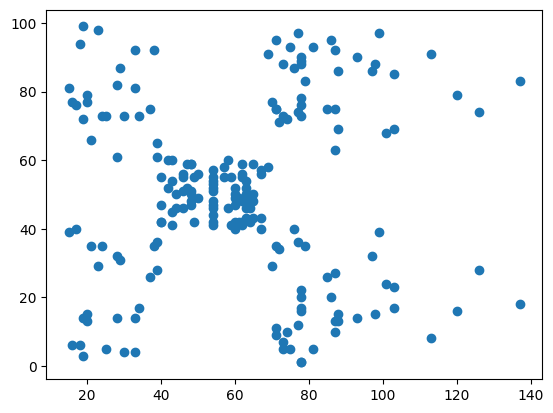

In [7]:
import matplotlib.pyplot as plt
plt.scatter(data['Income'],data['Score'])

In [11]:
from sklearn.cluster import KMeans
k_values = [1,2,3,4,5,6,7,8,9]
wcss_error = []
for k in k_values:
  model = KMeans(n_clusters=k)
  model.fit(data[['Income','Score']])
  wcss_error.append(model.inertia_)

In [12]:
wcss_error

[269981.28000000014,
 181363.59595959607,
 106348.37306211119,
 73679.78903948837,
 44448.45544793369,
 38792.367293075135,
 30566.45113025185,
 28405.406633906725,
 22967.00686305564]

Text(0, 0.5, 'WCSS Error')

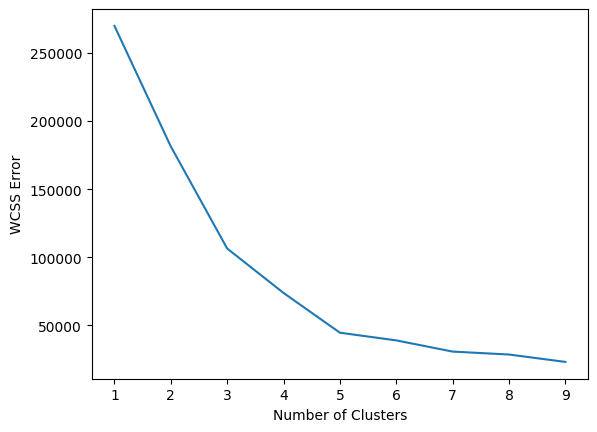

In [14]:
plt.plot(k_values,wcss_error)
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS Error')

In [16]:
from sklearn.cluster import KMeans
model = KMeans(n_clusters=5)
pred = model.fit_predict(data)

In [17]:
pred

array([4, 0, 4, 0, 4, 0, 4, 0, 4, 0, 4, 0, 4, 0, 4, 0, 4, 0, 4, 0, 4, 0,
       4, 0, 4, 0, 4, 0, 4, 0, 4, 0, 4, 0, 4, 0, 4, 0, 4, 0, 4, 0, 4, 3,
       4, 0, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 2, 1, 2, 3, 2, 1, 2, 1, 2,
       3, 2, 1, 2, 1, 2, 1, 2, 1, 2, 3, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2,
       1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2,
       1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2,
       1, 2], dtype=int32)

In [18]:
data['cluster']=pred
data.head(5)

,Income,Score,cluster
0,15,39,4
1,15,81,0
2,16,6,4
3,16,77,0
4,17,40,4


In [20]:
c1=data[data['cluster']==0]
c2=data[data['cluster']==1]
c3=data[data['cluster']==2]
c4=data[data['cluster']==3]
c5=data[data['cluster']==4]
c3.head(5)

,Income,Score,cluster
123,69,91,2
125,70,77,2
127,71,95,2
129,71,75,2
131,71,75,2


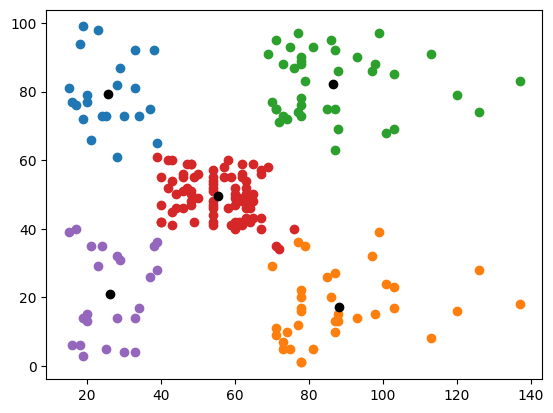

In [24]:
plt.scatter(c1['Income'],c1['Score'])
plt.scatter(c2['Income'],c2['Score'])
plt.scatter(c3['Income'],c3['Score'])
plt.scatter(c4['Income'],c4['Score'])
plt.scatter(c5['Income'],c5['Score'])
plt.scatter(model.cluster_centers_[:,0], model.cluster_centers_[:,1],color='black')

In [22]:
model.cluster_centers_

array([[25.72727273, 79.36363636],
       [88.2       , 17.11428571],
       [86.53846154, 82.12820513],
       [55.2962963 , 49.51851852],
       [26.30434783, 20.91304348]])